## 1. Kutuphaneler ve Veri Yukleme

In [2]:
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110
sns.set_style("whitegrid")

df = pd.read_csv("cleaned.csv", index_col=0)
print(f"Veri boyutu: {df.shape}")
df.head()

Veri boyutu: (12205, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
print(f"Veri boyutu : {df.shape}")
print("-" * 40)
df.info()
print("-" * 40)
print("Eksik deger:\n", df.isnull().sum())
print("-" * 40)
print("Tekrar eden satir:", df.duplicated().sum())

Veri boyutu : (12205, 18)
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 12205 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12205 non-null  int64  
 1   Administrative_Duration  12205 non-null  float64
 2   Informational            12205 non-null  int64  
 3   Informational_Duration   12205 non-null  float64
 4   ProductRelated           12205 non-null  int64  
 5   ProductRelated_Duration  12205 non-null  float64
 6   BounceRates              12205 non-null  float64
 7   ExitRates                12205 non-null  float64
 8   PageValues               12205 non-null  float64
 9   SpecialDay               12205 non-null  float64
 10  Month                    12205 non-null  object 
 11  OperatingSystems         12205 non-null  int64  
 12  Browser                  12205 non-null  int64  
 13  Region        

## 2. Hedef Degisken Analizi

`Revenue`: kullanicinin o oturumda satin alim yapip yapmadigini gosteren ikili degisken.

Revenue
False    0.8437
True     0.1563
Name: proportion, dtype: float64


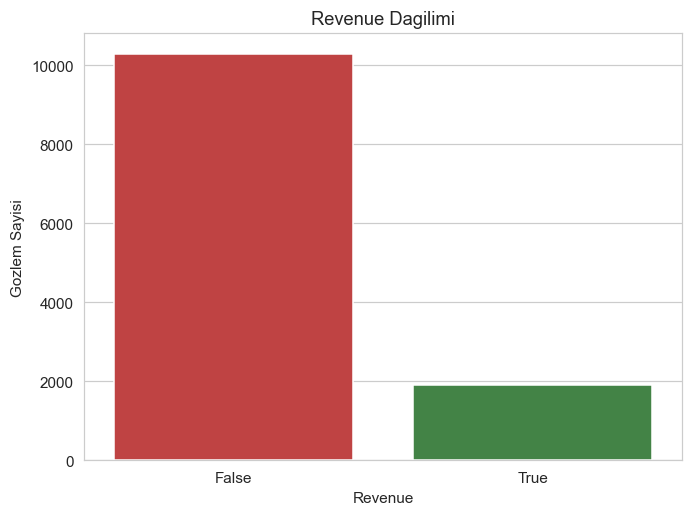

In [4]:
print(df["Revenue"].value_counts(normalize=True).round(4))

sns.countplot(
    data=df,
    x="Revenue",
    hue="Revenue",
    palette={False: "#d32f2f", True: "#388e3c"},
    legend=False,
)
plt.title("Revenue Dagilimi")
plt.xlabel("Revenue")
plt.ylabel("Gozlem Sayisi")
plt.tight_layout()
plt.show()

Kullanicilarin yaklasik **%84'u** herhangi bir satin alim gerceklestirmemistir.
Veri seti, hedef degisken acisindan belirgin sekilde dengesizdir.
Model egitiminde `class_weight='balanced'` parametresi kullanilmasi ya da
yeniden ornekleme (resampling) yontemlerine basvurulmasi gerekebilir.
Degerlendirme metrikleri de bu dengesizlik goz onunde bulundurularak secilmistir.

## 3. Sayisal Degiskenlerde Korelasyon Analizi

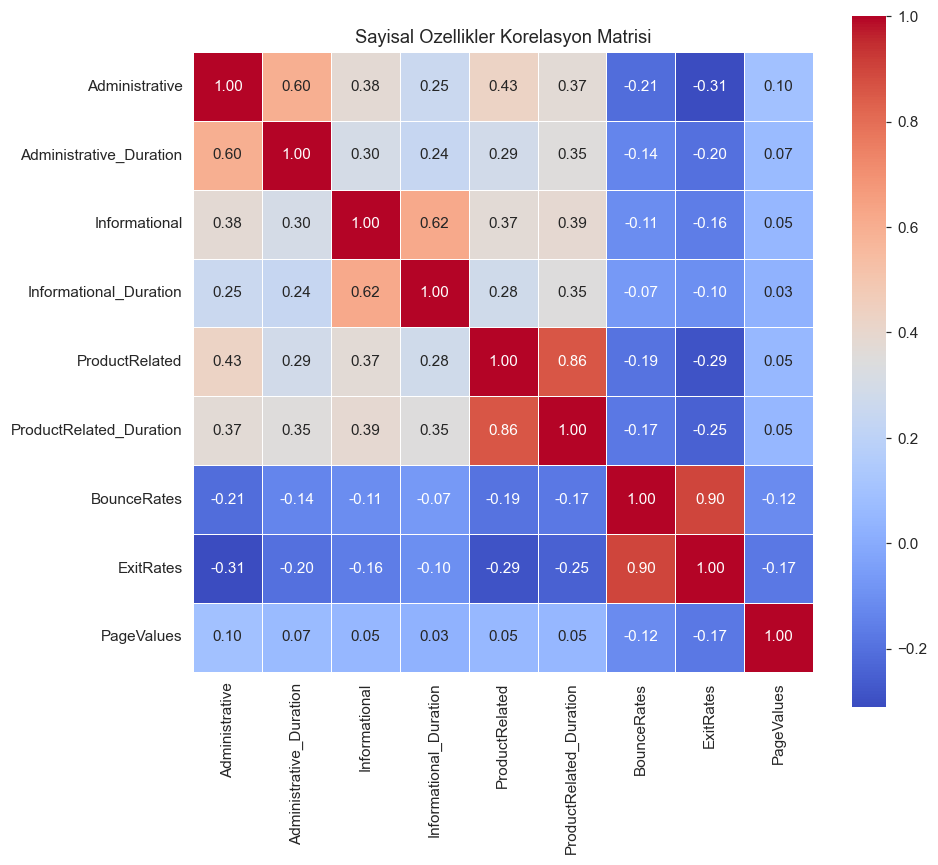

In [5]:
numeric_cols = [
    "Administrative", "Administrative_Duration",
    "Informational", "Informational_Duration",
    "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates", "PageValues",
]
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(9, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True,
    linewidths=0.4,
)
plt.title("Sayisal Ozellikler Korelasyon Matrisi")
plt.tight_layout()
plt.show()

In [6]:
# En yuksek korelasyona sahip esler
pairs = corr_matrix.abs().unstack()
sorted_pairs = pairs[pairs < 1.0].sort_values(ascending=False).drop_duplicates()
print("En yuksek korelasyona sahip ozellik ciftleri:")
print(sorted_pairs.head(10).to_string())

En yuksek korelasyona sahip ozellik ciftleri:
ExitRates                BounceRates                0.902144
ProductRelated           ProductRelated_Duration    0.860330
Informational_Duration   Informational              0.618648
Administrative_Duration  Administrative             0.600457
Administrative           ProductRelated             0.428305
Informational            ProductRelated_Duration    0.386052
                         Administrative             0.375256
ProductRelated           Informational              0.372572
Administrative           ProductRelated_Duration    0.371146
ProductRelated_Duration  Administrative_Duration    0.353583


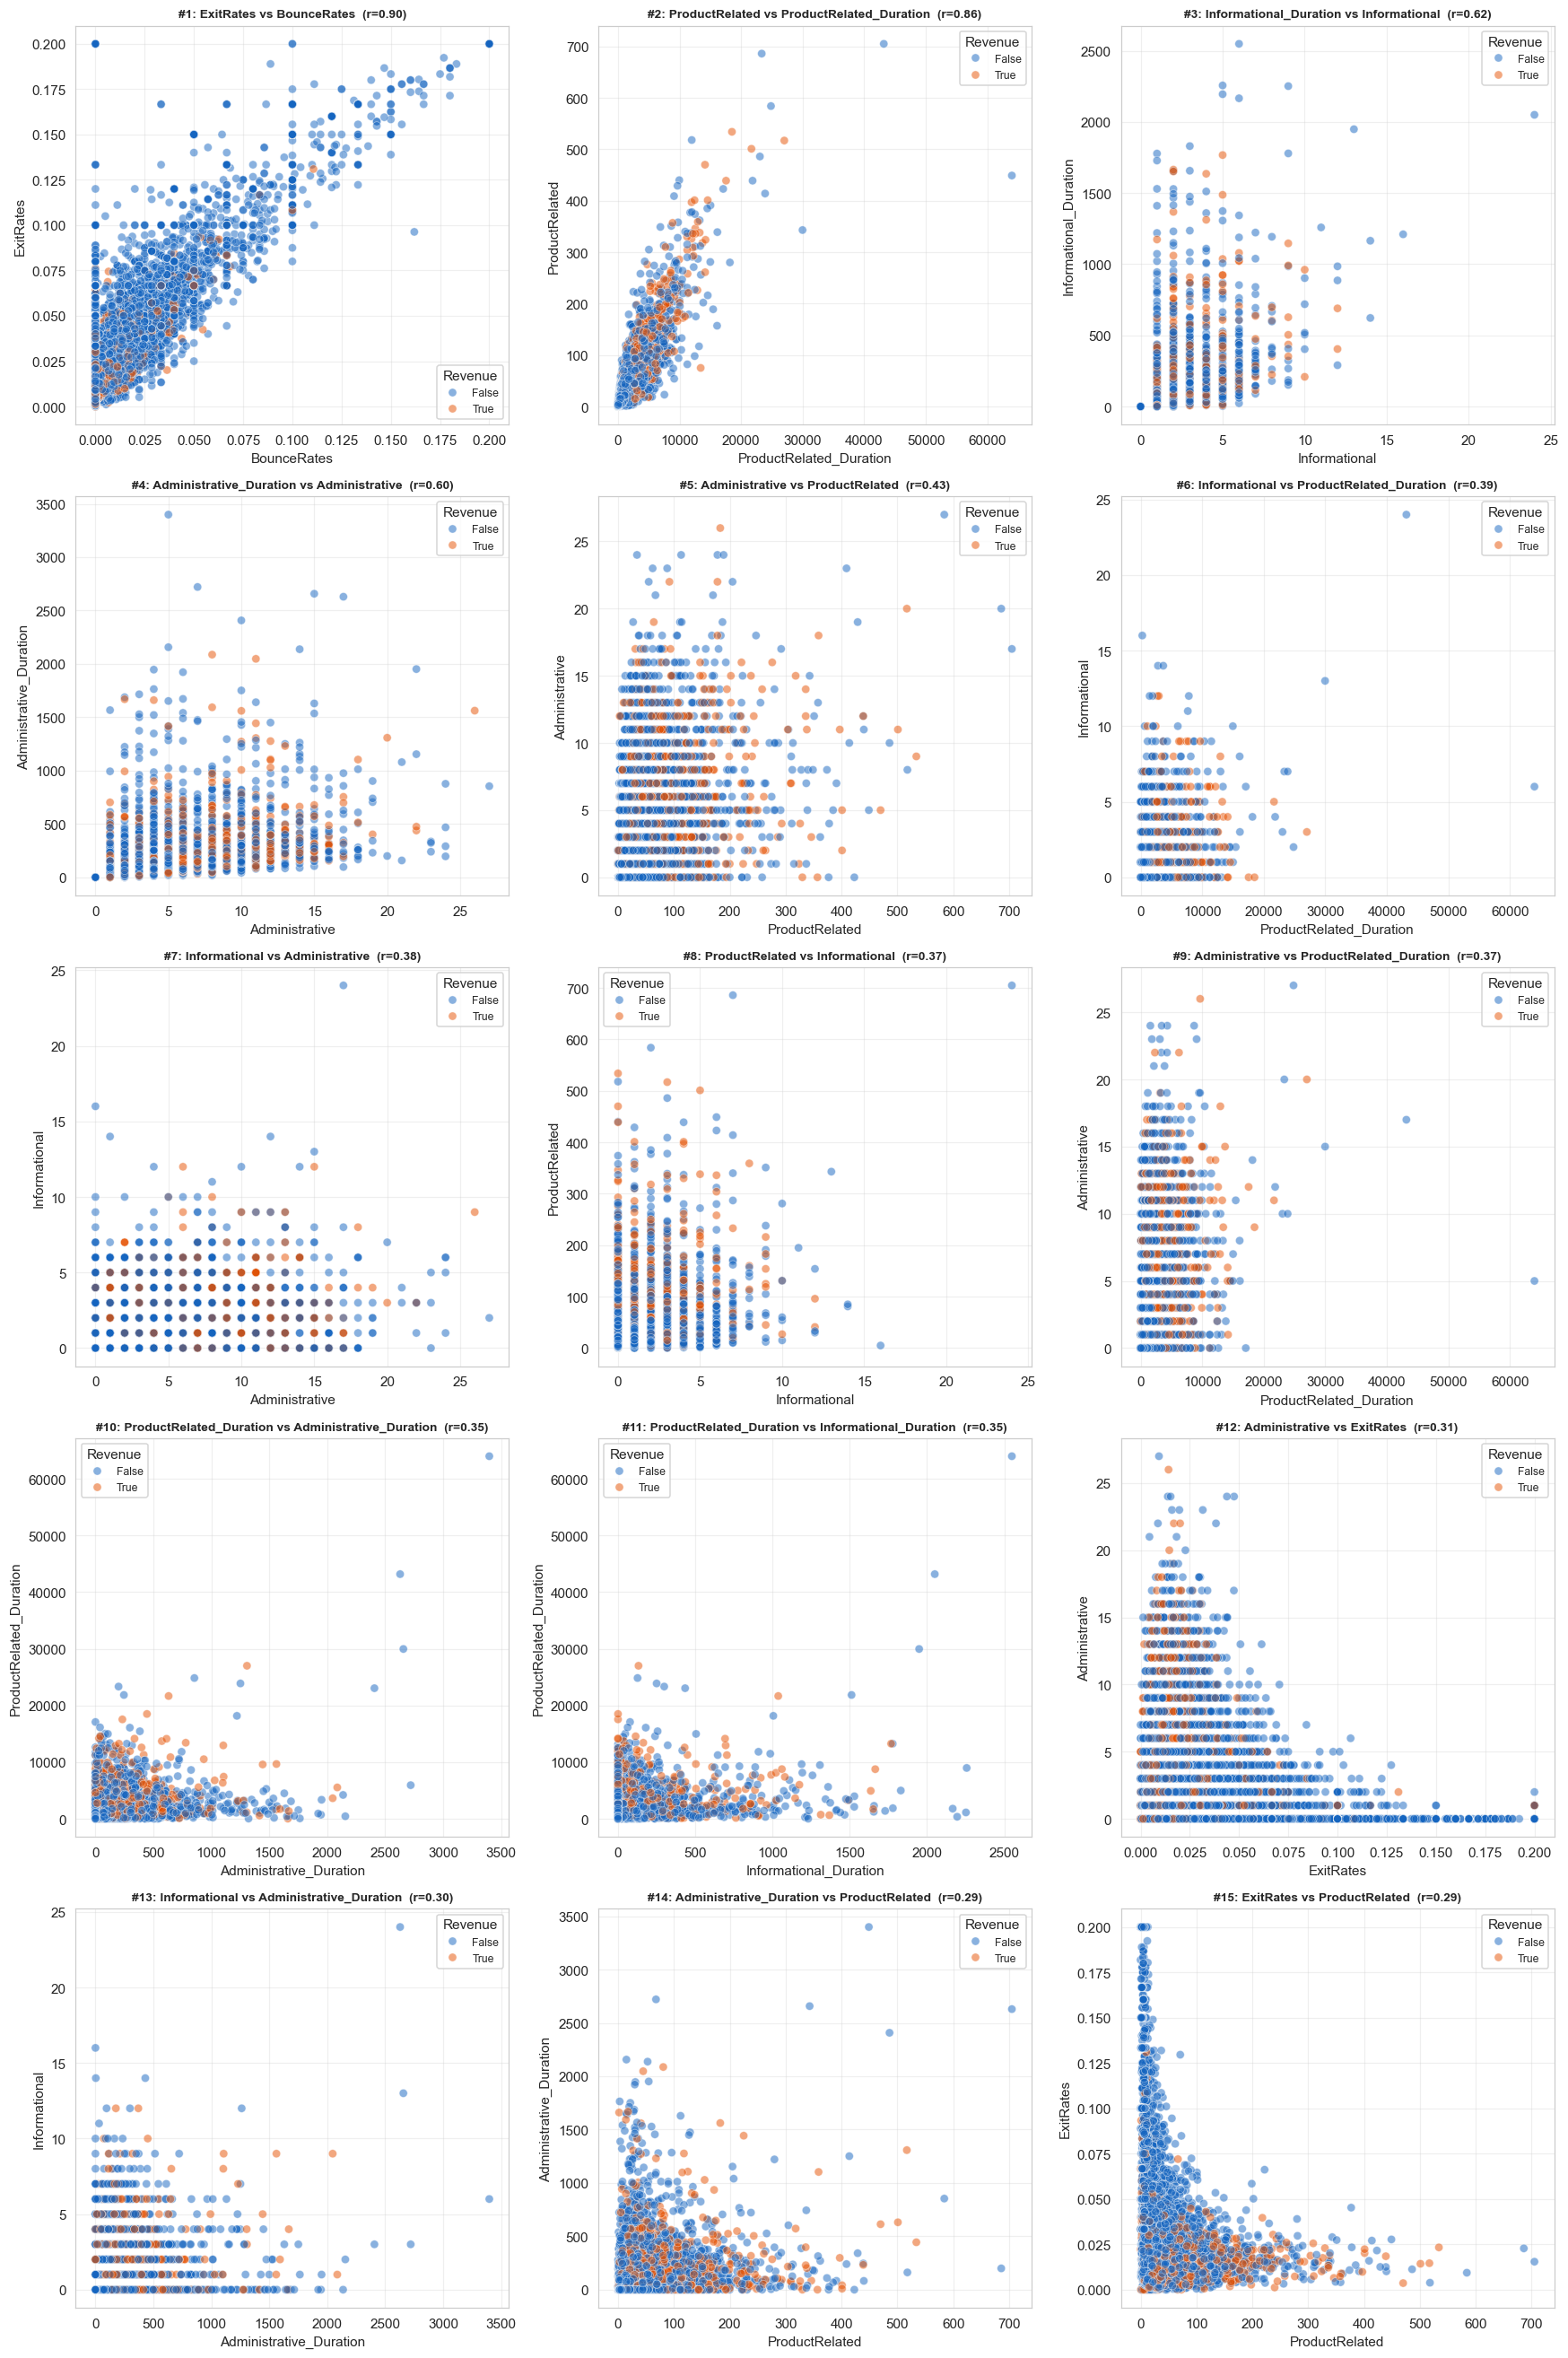

In [7]:
top_pairs = sorted_pairs.head(15)
fig, axes = plt.subplots(5, 3, figsize=(16, 24))
axes = axes.flatten()

for i, ((col1, col2), corr_val) in enumerate(top_pairs.items()):
    sns.scatterplot(
        data=df,
        x=col2,
        y=col1,
        hue="Revenue",
        palette={False: "#1565c0", True: "#e65100"},
        alpha=0.5,
        ax=axes[i],
    )
    axes[i].set_title(
        f"#{i + 1}: {col1} vs {col2}  (r={corr_val:.2f})",
        fontweight="bold",
        fontsize=9,
    )
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(title="Revenue", fontsize=8)

plt.tight_layout()
plt.show()

Beklendigi uzere, bir sayfayla ilgili ziyaret sayisi ile gecirilen sure arasinda
(ornegin `ProductRelated` / `ProductRelated_Duration`) yuksek korelasyon
bulunmaktadir.
`BounceRates` ve `ExitRates` arasindaki korelasyon da yuksektir; bu iki
degiskenden birinin model icin cikarilmasi coklu baglantiyi (multicollinearity)
azaltacaktir.

## 4. Kategorik Degisken Analizi

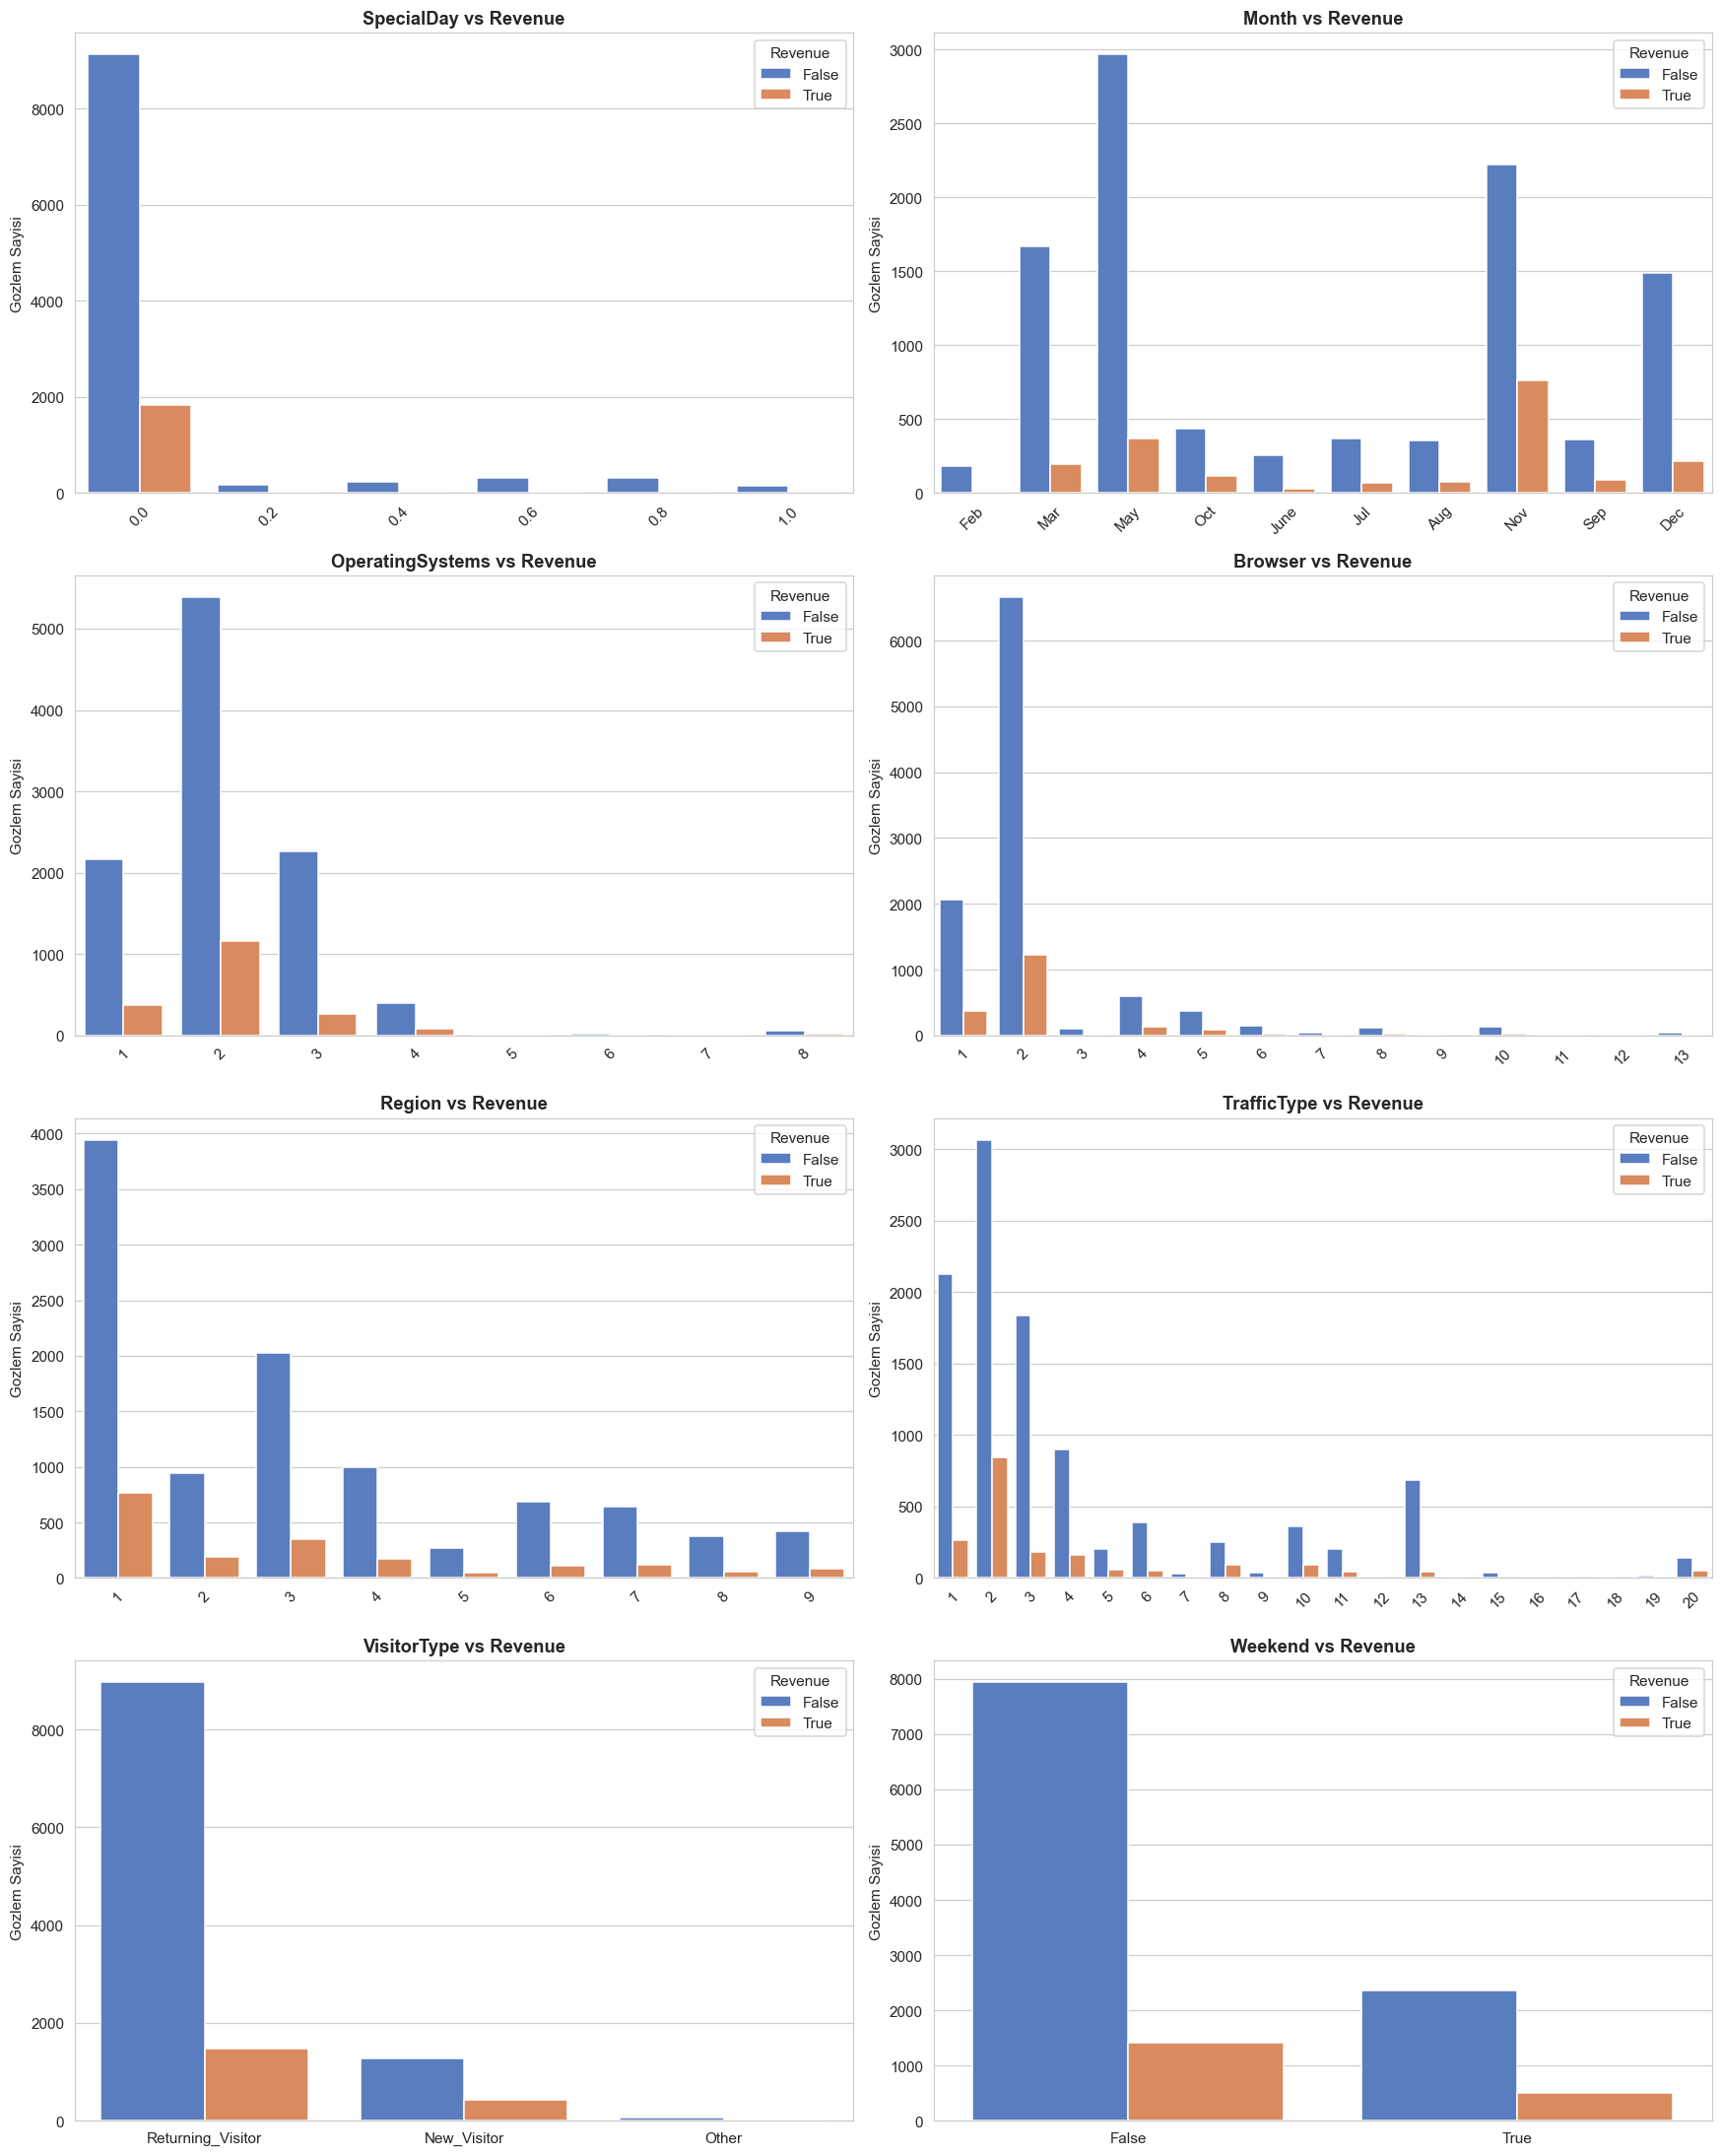

In [8]:
cat_cols = [
    "SpecialDay", "Month", "OperatingSystems", "Browser",
    "Region", "TrafficType", "VisitorType", "Weekend",
]

n_cols = 2
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(
        data=df, x=col, hue="Revenue",
        ax=axes[i], palette="muted",
    )
    axes[i].set_title(f"{col} vs Revenue", fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Gozlem Sayisi")
    axes[i].legend(title="Revenue", loc="upper right")
    if df[col].nunique() > 5:
        axes[i].tick_params(axis="x", rotation=45)

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

- Trafik kaynagi 1, 2 ve 3 en yuksek ziyaret ve satin alim sayilarini olusturmaktadir.
- Mart, Mayis, Kasim ve Aralik aylari en yuksek trafige sahip donemlerdir;
  kampanya donemlerinin (Dunya Kadinlar Gunu, Anneler Gunu, Black Friday) bu
  yogunlukla ortusmesi rastlanti degildir.

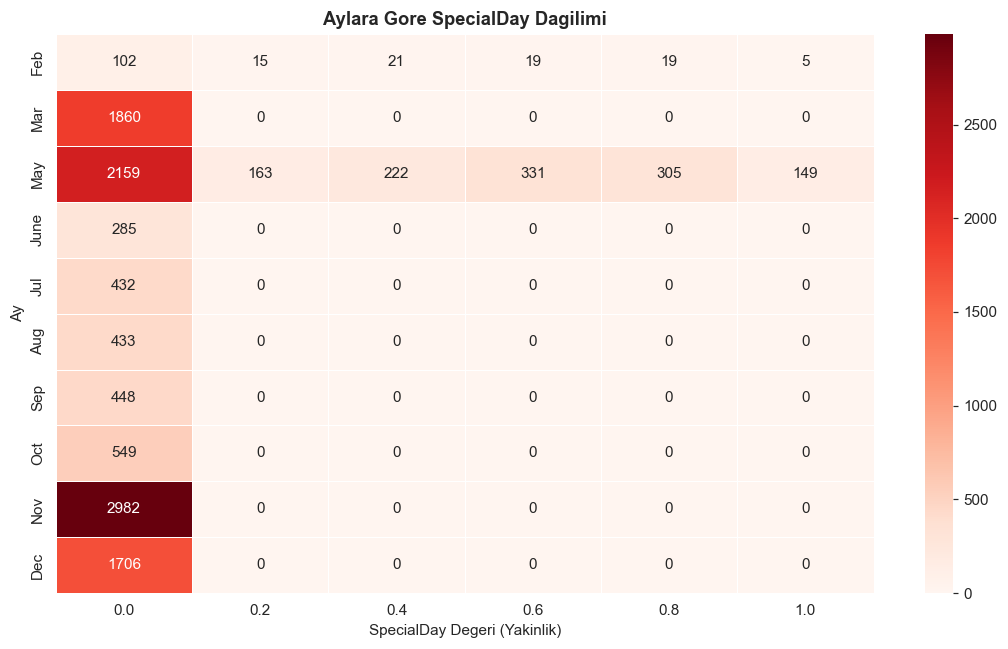

In [9]:
month_order = ["Feb", "Mar", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
crosstab = pd.crosstab(df["Month"], df["SpecialDay"]).reindex(month_order)

plt.figure(figsize=(10, 6))
sns.heatmap(
    crosstab, annot=True, fmt="d",
    cmap="Reds", linewidths=0.5,
)
plt.title("Aylara Gore SpecialDay Dagilimi", fontweight="bold")
plt.xlabel("SpecialDay Degeri (Yakinlik)")
plt.ylabel("Ay")
plt.tight_layout()
plt.show()

`SpecialDay` degiskeni yalnizca Subat (Sevgililer Gunu) ve Mayis (Anneler Gunu)
aylarini kapsamaktadir. Black Friday, veri setinde ozel gun olarak kodlanmamistir;
ancak Kasim ayi istatistikleri bu donemde guclu bir satis artisinin yasandigini
gostermektedir.

## 5. Aylik Exit Rate Analizi

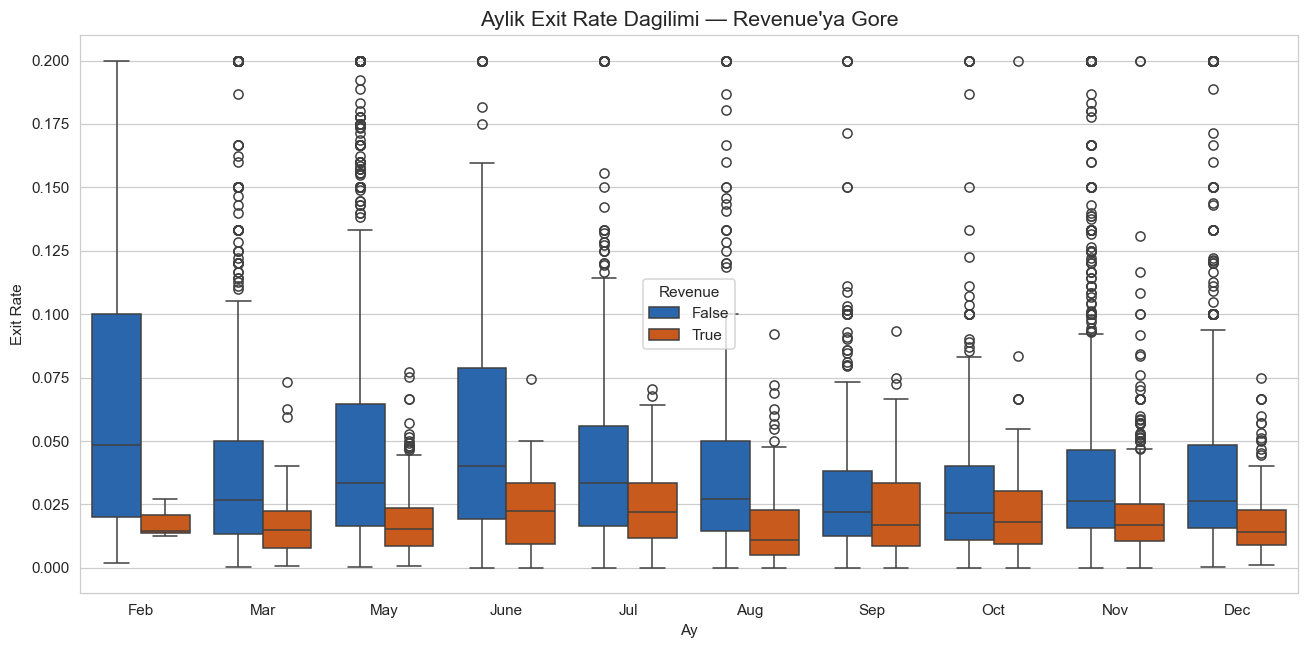

In [10]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df, x="Month", y="ExitRates", hue="Revenue",
    order=month_order,
    palette={False: "#1565c0", True: "#e65100"},
)
plt.title("Aylik Exit Rate Dagilimi — Revenue'ya Gore", fontsize=14)
plt.xlabel("Ay")
plt.ylabel("Exit Rate")
plt.legend(title="Revenue")
plt.tight_layout()
plt.show()

Satin alim gerceklestiren kullanicilarin exit rate dagilimi dar ve asagida
yogunlasirken, satin almayanlarin dagilimi sagdan kuyruklu ve aykirilara aciktir.
Bu durum ozellikle kampanya aylarinda (Mayis, Kasim) belirginlesir; kampanyadan
haberdar olup siteye gelen ancak karar veremeyen kullanicilarin yuksek cikis
oranlarindan kaynaklanmis olabilir.

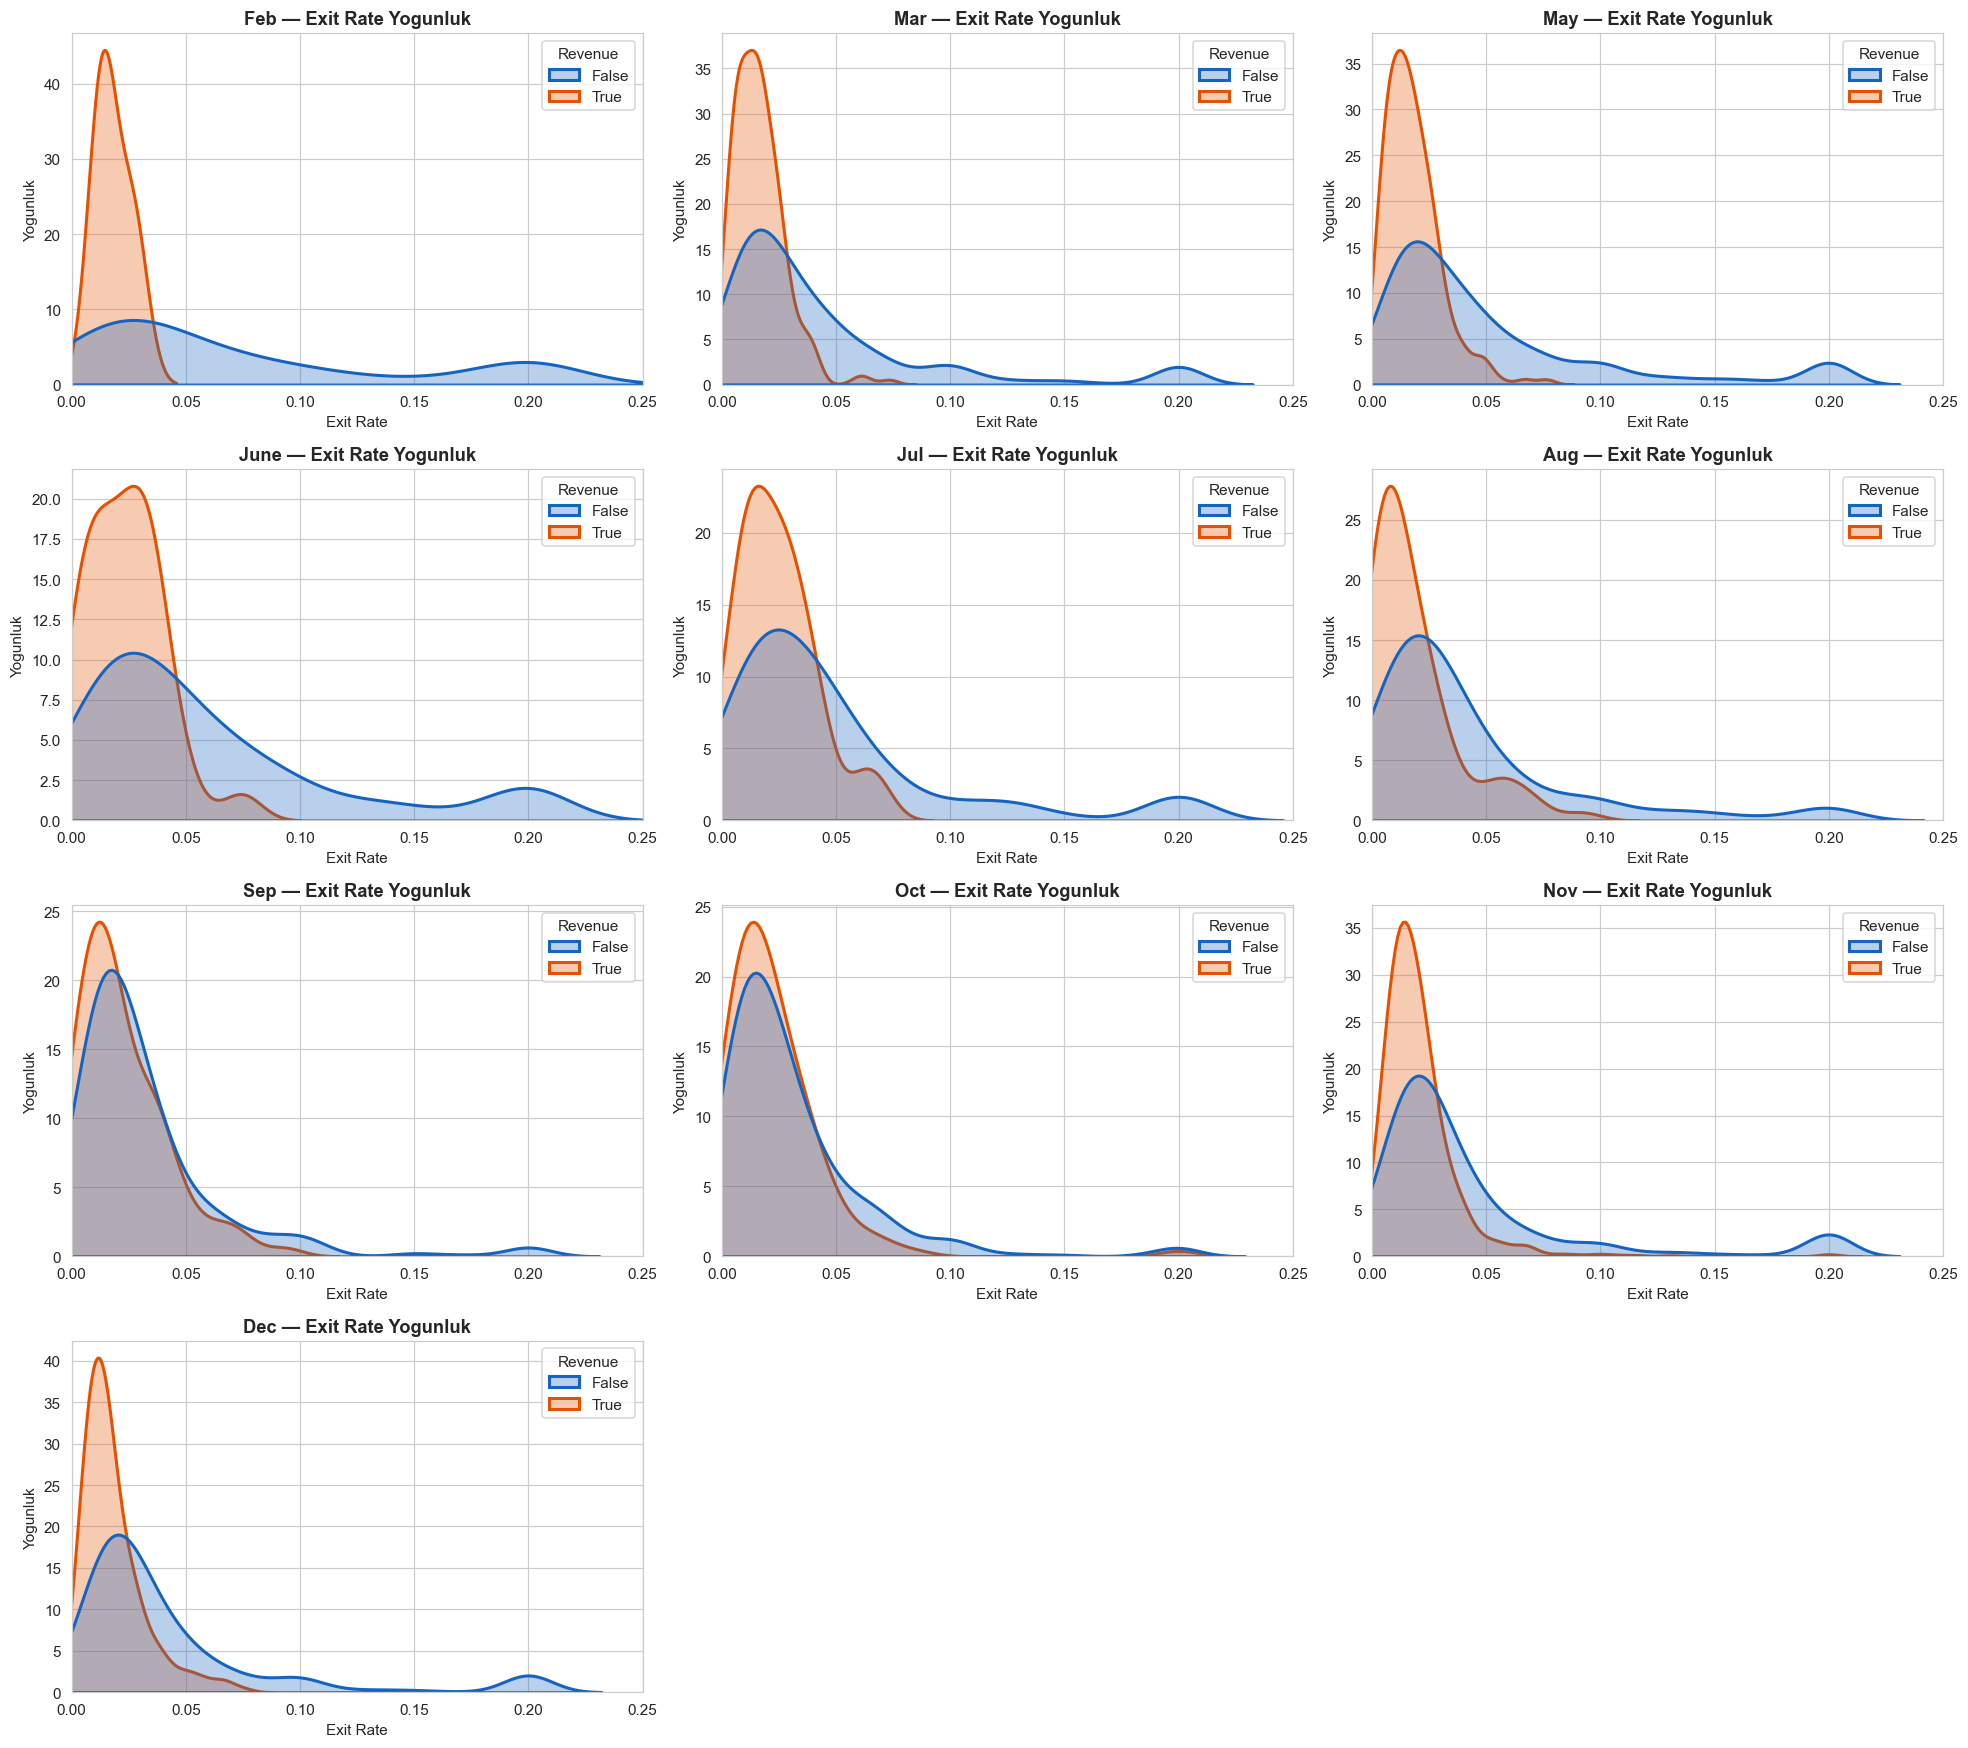

In [11]:
n_cols, n_rows = 3, math.ceil(len(month_order) / 3)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, month in enumerate(month_order):
    sns.kdeplot(
        data=df[df["Month"] == month],
        x="ExitRates",
        hue="Revenue",
        ax=axes[i],
        palette={False: "#1565c0", True: "#e65100"},
        fill=True, alpha=0.3, linewidth=2, common_norm=False,
    )
    axes[i].set_title(f"{month} — Exit Rate Yogunluk", fontweight="bold")
    axes[i].set_xlim(0, 0.25)
    axes[i].set_xlabel("Exit Rate")
    axes[i].set_ylabel("Yogunluk")

for j in range(len(month_order), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Subat, Mart ve Mayis aylarinda exit rate esigi 0.05 civarinda ikiye ayrilan
net bir sinir olusturmaktadir: bu esigi asan kullanicilarin neredeyse tamami
satin alim yapmamistir. Diger aylarda bu sinir 0.10'a yaklasir.
Exit Rate, modelin ayirt ediciligi acisindan en guclu sayisal degiskenler
arasinda yer almaktadir.

## 6. Baseline Model — Logistic Regression

Karsilastirma referansi olusturmak amaci ile basit bir Logistic Regression modeli
kurulmaktadir. Preprocessing adimlarinin tamamlanmis hali ilerleyen notebook'larda
(Segmentation, Classification) yeniden kullanilacaktir.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [13]:
df_model = df.copy()

# SpecialDay'i ikili degiskene donustur
df_model["Is_SpecialDay"] = (df_model["SpecialDay"] > 0).astype(int)
df_model.drop(columns=["SpecialDay"], inplace=True)

# BounceRates cikarilarak multicollinearity azaltilir
df_model.drop(columns=["BounceRates"], inplace=True)

df_model["Revenue"] = df_model["Revenue"].astype(int)

# Kategorik kodlama
cat_cols = ["Month", "OperatingSystems", "Browser", "Region",
            "TrafficType", "VisitorType", "Weekend"]
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

X = df_model.drop(columns=["Revenue"])
y = df_model["Revenue"]

# Sinif oranini koruyarak bolme (stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Egitim seti : {X_train_sc.shape}")
print(f"Test seti   : {X_test_sc.shape}")
print(f"\nSinif dagilimi (egitim):\n{y_train.value_counts(normalize=True).round(4)}")

Egitim seti : (9764, 67)
Test seti   : (2441, 67)

Sinif dagilimi (egitim):
Revenue
0    0.8437
1    0.1563
Name: proportion, dtype: float64


In [14]:
baseline = LogisticRegression(
    random_state=42,
    class_weight="balanced",
    max_iter=1000,
)
baseline.fit(X_train_sc, y_train)

y_pred = baseline.predict(X_test_sc)
y_prob = baseline.predict_proba(X_test_sc)[:, 1]

print("--- Baseline Model Performansi ---")
print(classification_report(y_test, y_pred, target_names=["No Revenue", "Revenue"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

--- Baseline Model Performansi ---
              precision    recall  f1-score   support

  No Revenue       0.96      0.85      0.90      2059
     Revenue       0.50      0.80      0.62       382

    accuracy                           0.85      2441
   macro avg       0.73      0.83      0.76      2441
weighted avg       0.89      0.85      0.86      2441

ROC-AUC: 0.9083


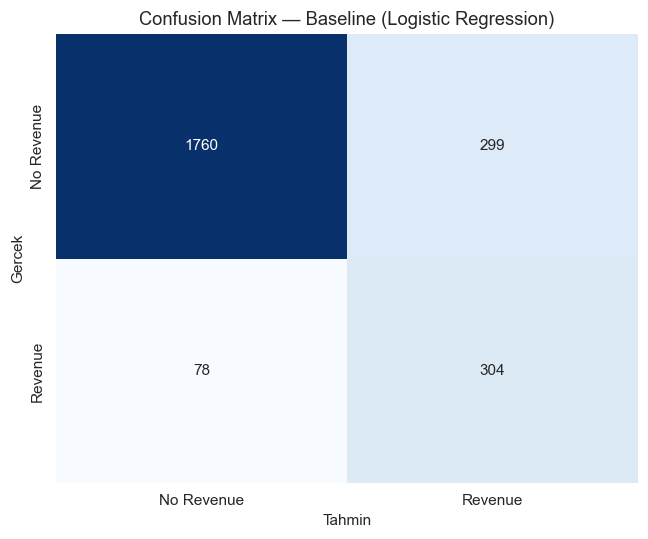

In [15]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=["No Revenue", "Revenue"],
    yticklabels=["No Revenue", "Revenue"],
)
plt.title("Confusion Matrix — Baseline (Logistic Regression)")
plt.xlabel("Tahmin")
plt.ylabel("Gercek")
plt.tight_layout()
plt.show()

| Metrik | Deger |
|---|---|
| ROC-AUC | ~0.91 |
| Recall (Revenue=1) | ~0.80 |
| Precision (Revenue=1) | ~0.51 |
| F1 (Revenue=1) | ~0.62 |

Model, 382 gercek alicinin 304'ünü (%79) dogru siniflandirmaktadir.
False Positive sayisi (299) yuksektir; bu durum precision degerini
asagi cekmekte ve gereksiz pazarlama maliyetine yol acmaktadir.
Recall onceligi bu problem icin makul bir tercih olmakla birlikte,
karar esigi ayari ile precision-recall dengesi iyilestirilebilir.